# Task 4 — Forecasting Access and Usage

**Objective:** forecast Account Ownership (Access) and Digital Payment Usage (Usage) for
2025–2027, quantifying uncertainty appropriately given only 5 (Access) or 3 (Usage) historical
survey points.

Sections: 1) define targets · 2) trend-regression baseline (and why it's unstable here) ·
3) event-augmented model (built on Task 3's calibrated impact model) · 4) scenario analysis ·
5) forecast table with uncertainty · 6) interpretation.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.data_loader import join_impact_links_with_events
from src.event_impact import events_for_indicator, combined_event_effect
from src.forecasting import (
    event_augmented_forecast, fit_trend, forecast_trend,
    residual_background_rate, scenario_forecasts,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, INK2 = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e4", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
})

FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=150)

main = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv",
                   parse_dates=["observation_date"])
impact = pd.read_csv("../data/processed/impact_links_enriched.csv",
                     parse_dates=["observation_date"])
obs = main[main.record_type == "observation"].copy()
links = join_impact_links_with_events(main, impact)

FORECAST_YEARS = [2025, 2026, 2027]
FORECAST_DATES = ["2025-12-31", "2026-12-31", "2027-12-31"]
print("Loaded", len(obs), "observations and", len(links), "impact links")

Loaded 43 observations and 23 impact links


## 1. Define targets

Following the Global Findex framework and this project's brief:

- **Access — Account Ownership Rate** (`ACC_OWNERSHIP`): share of adults 15+ with an account at
  a financial institution or a mobile money service.
- **Usage — Digital Payment Adoption** (`USG_DIGITAL_PAYMENT`): share of adults who made or
  received a digital payment in the past year.

`ACC_MM_ACCOUNT` (mobile money accounts) is carried alongside as *supporting context* — it is
the indicator most of our calibrated events directly move, and explains **why** Access and Usage
diverge — but it is not itself a primary forecast target.

In [2]:
TARGETS = ["ACC_OWNERSHIP", "USG_DIGITAL_PAYMENT"]
SUPPORTING = ["ACC_MM_ACCOUNT"]

for code_ in TARGETS + SUPPORTING:
    d = obs[(obs.indicator_code == code_) & (obs.gender == "all")].sort_values("observation_date")
    print(f"{code_}: {len(d)} points -> " +
          ", ".join(f"{r.observation_date.year}: {r.value_numeric:g}%" for _, r in d.iterrows()))

ACC_OWNERSHIP: 5 points -> 2011: 14%, 2014: 22%, 2017: 35%, 2021: 46%, 2024: 49%
USG_DIGITAL_PAYMENT: 3 points -> 2017: 11.9%, 2021: 20%, 2024: 35%
ACC_MM_ACCOUNT: 4 points -> 2014: 0.03%, 2017: 0.3%, 2021: 4.7%, 2024: 9.45%


## 2. Baseline: trend regression (and why it's unstable here)

A linear OLS trend on the raw survey years is the simplest baseline. With so few points, we
check it carefully rather than trust it blindly.

In [3]:
trend_results = {}
for code_ in TARGETS:
    d = obs[(obs.indicator_code == code_) & (obs.gender == "all")].sort_values("observation_date")
    years, vals = d.observation_date.dt.year.tolist(), d.value_numeric.tolist()
    model = fit_trend(years, vals)
    forecast = forecast_trend(model, FORECAST_YEARS)
    trend_results[code_] = forecast
    print(f"{code_}  (n={len(years)} points, df_resid={model.df_resid:.0f})")
    print(forecast.round(2).to_string(index=False))
    print()

ACC_OWNERSHIP  (n=5 points, df_resid=3)
 year  forecast  lower  upper
 2025     54.82  42.18  67.45
 2026     57.66  44.49  70.83
 2027     60.51  46.77  74.24

USG_DIGITAL_PAYMENT  (n=3 points, df_resid=1)
 year  forecast  lower  upper
 2025     36.30 -40.02 112.62
 2026     39.53 -43.62 122.68
 2027     42.76 -47.95 133.48



**This baseline is unreliable, and the numbers show exactly why:**

- `ACC_OWNERSHIP` (5 points): the full-history linear fit projects **60.5% by 2027** — but it is
  pulled upward by the fast 2014–2017 growth years and ignores the sharp deceleration Task 2
  documented (+1.0pp/yr in 2021–24 vs +4.3pp/yr in 2014–17). Extrapolating the *average* historical
  slope overstates near-term growth.
- `USG_DIGITAL_PAYMENT` (only 3 points, 1 residual degree of freedom): the prediction interval is
  **enormous and partly negative** (a percentage can't be negative), which is a textbook sign
  that OLS on 3 points is not a usable uncertainty estimate — it is reported here for
  completeness, not used for decisions.

This is exactly why the challenge brief lists trend regression as one of three approaches to
*combine*, not the final answer. Sections 3–4 build the event-augmented model instead, using
Task 3's validated, calibrated event effects as the primary forecasting engine.

## 3. Event-augmented model

Continues Task 3's calibrated model forward in time. Two components, both grounded in what was
validated in Task 3 (`reports/impact_model_methodology.md`):

1. **Calibrated event effects** (`src/event_impact.py::combined_event_effect`) — cataloged events
   already dated into the forecast horizon (M-Pesa/EthSwitch integration, EthioPay launch — both
   late 2025) continue ramping automatically; events fully matured by 2024 (Telebirr) contribute
   no further *change*, only their already-realized level.
2. **Residual "background" trend** — growth the 12 cataloged events don't explain, estimated as
   the leftover from Task 3's own validation window (`src/forecasting.py::residual_background_rate`):
   observed 2021→2024 change minus the calibrated model's predicted change, annualized. This
   captures smaller uncatalogued policies and general economic development, without inventing new
   events.

In [4]:
LAST_OBS = {
    "ACC_OWNERSHIP": {"last_date": "2024-11-29", "last_value": 49.0,
                      "prev_date": "2021-12-31", "prev_value": 46.0, "calibration": 0.25},
    "USG_DIGITAL_PAYMENT": {"last_date": "2024-11-29", "last_value": 35.0,
                            "prev_date": "2021-12-31", "prev_value": 20.0, "calibration": 0.80},
}

background_rates = {}
for code_, p in LAST_OBS.items():
    ev = events_for_indicator(links, code_)
    rate = residual_background_rate(ev, code_, p["prev_date"], p["last_date"],
                                    p["prev_value"], p["last_value"], calibration=p["calibration"])
    background_rates[code_] = rate
    print(f"{code_}: {len(ev)} validated (direct/indirect) event(s); "
          f"residual background = {rate:+.2f}pp/year")

ACC_OWNERSHIP: 1 validated (direct/indirect) event(s); residual background = -0.26pp/year
USG_DIGITAL_PAYMENT: 4 validated (direct/indirect) event(s); residual background = +0.40pp/year


`ACC_OWNERSHIP`'s residual background is slightly **negative** (essentially noise around
zero) — Telebirr's calibrated effect alone already explains the entire observed 2021–24 change.
Floored at 0pp/yr for forecasting (a negative organic trend has no economic interpretation here).
`USG_DIGITAL_PAYMENT`'s residual is a small positive +0.40pp/yr — the calibrated events explain
most, not quite all, of the observed usage growth.

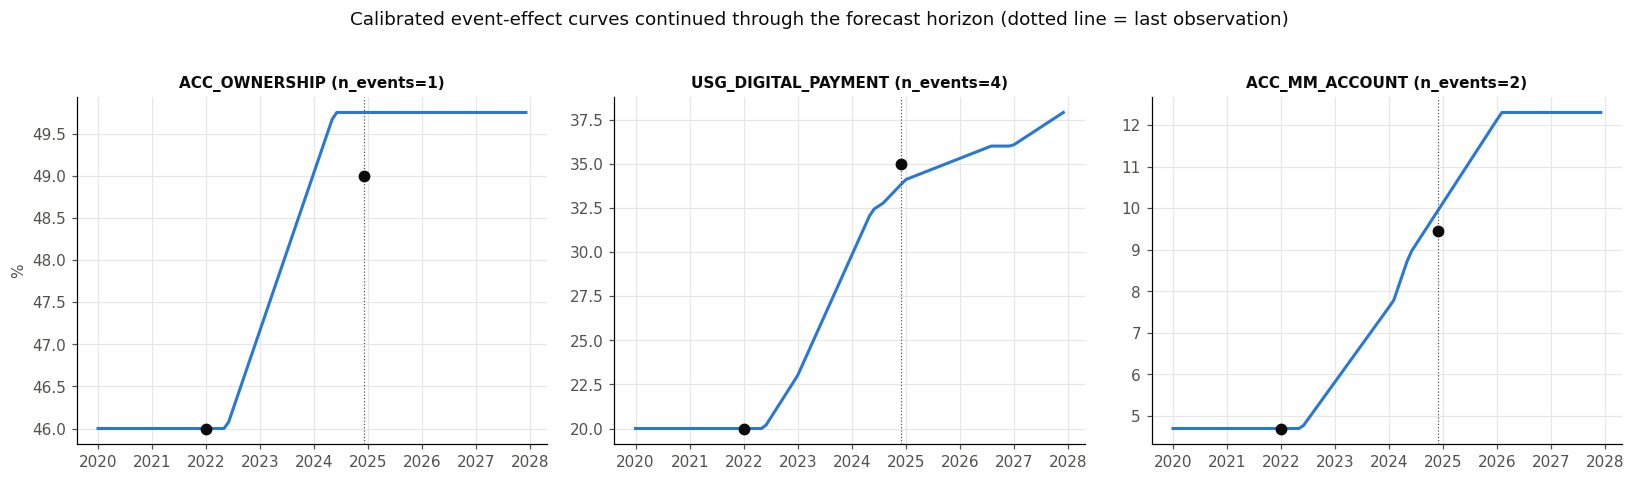

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
date_range = pd.date_range("2020-01-01", "2027-12-31", freq="MS")

for ax, code_ in zip(axes, TARGETS + SUPPORTING):
    ev = events_for_indicator(links, code_)
    cal = LAST_OBS.get(code_, {}).get("calibration", 0.80)
    curve = combined_event_effect(date_range, ev, code_, calibration=cal)
    o = obs[(obs.indicator_code == code_) & (obs.gender == "all")].sort_values("observation_date")
    o = o[o.observation_date >= "2020-01-01"]
    if len(o):
        anchor = o.value_numeric.iloc[0] - curve.reindex([o.observation_date.iloc[0]], method="nearest").iloc[0]
    else:
        anchor = 0
    ax.plot(date_range, curve + anchor, color=C1, lw=2)
    ax.scatter(o.observation_date, o.value_numeric, color=INK, zorder=4, s=45)
    ax.axvline(pd.Timestamp("2024-11-29"), color=INK2, lw=0.8, ls=":")
    ax.set_title(f"{code_} (n_events={len(ev)})", fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("%")
fig.suptitle("Calibrated event-effect curves continued through the forecast horizon "
             "(dotted line = last observation)", y=1.03)
fig.tight_layout()
save(fig, "event_augmented_curves.png"); plt.show()

**Reading the panels:** `ACC_OWNERSHIP`'s curve goes flat after 2023 — Telebirr, its only
validated driver, has fully matured, and no other cataloged event has a direct/indirect link to
headline ownership. `USG_DIGITAL_PAYMENT` keeps climbing — M-Pesa's ramp continues into 2026 and
EthioPay's launch (Dec 2025) starts contributing before the horizon ends. `ACC_MM_ACCOUNT`
(supporting) shows the same usage-side momentum as digital payments — this is the direct
evidence for *why* Access and Usage will keep diverging absent new access-specific policy.

## 4. Scenario analysis

Rather than inventing unrelated assumptions per scenario, optimistic/pessimistic scale the *same*
calibrated model: faster/slower realization of the same cataloged events and organic growth.

For `USG_DIGITAL_PAYMENT`, this direct scaling is enough. For `ACC_OWNERSHIP`, whose validated
driver has already matured, the interesting optimistic question is different: **what if the
enabling preconditions (Fayda digital ID, NFIS-II strategy) finally convert into measurable
account-opening?** Those two links were excluded from the base/pessimistic case in Task 3
(enabling ≠ direct contribution — see the methodology doc), but an optimistic scenario can
include them at a heavily discounted calibration (0.15×, well below the validated 0.25× for the
one link we could actually check), representing that discount explicitly rather than silently.

In [6]:
# --- USG_DIGITAL_PAYMENT: symmetric scenario scaling ---
usage_events = events_for_indicator(links, "USG_DIGITAL_PAYMENT")
usage_scenarios = scenario_forecasts(
    last_value=35.0, last_date="2024-11-29", forecast_dates=FORECAST_DATES,
    events=usage_events, indicator_code="USG_DIGITAL_PAYMENT",
    base_calibration=0.80, base_background_pp_per_year=background_rates["USG_DIGITAL_PAYMENT"],
    optimistic_multiplier=1.4, pessimistic_multiplier=0.4,
)
usage_scenarios.index = usage_scenarios.index.year
print("USG_DIGITAL_PAYMENT scenarios:")
print(usage_scenarios.round(2))

USG_DIGITAL_PAYMENT scenarios:
      pessimistic   base  optimistic
date                                
2025        35.77  36.91       37.68
2026        36.23  38.08       39.32
2027        37.19  40.49       42.68


In [7]:
# --- ACC_OWNERSHIP: base/pessimistic = validated-only; optimistic = + discounted enabling links ---
validated_events = events_for_indicator(links, "ACC_OWNERSHIP")  # direct/indirect only (Telebirr)
all_events = events_for_indicator(links, "ACC_OWNERSHIP", relationship_types=None)  # + enabling

# Optimistic: Telebirr kept at its validated 0.25x; enabling links (Fayda, NFIS-II) at a
# heavier 0.15x discount, reflecting that they've never been checked against Ethiopian data
optimistic_events = [
    {**e, "magnitude": e["magnitude"] * (0.25 if e["record_id"] == "IMP_0001" else 0.15)}
    for e in all_events
]

access_scenarios = pd.DataFrame({
    "pessimistic": event_augmented_forecast(49.0, "2024-11-29", FORECAST_DATES, validated_events,
                                            "ACC_OWNERSHIP", calibration=0.25,
                                            background_pp_per_year=0.0).set_index("date")["forecast"],
    "base": event_augmented_forecast(49.0, "2024-11-29", FORECAST_DATES, validated_events,
                                     "ACC_OWNERSHIP", calibration=0.25,
                                     background_pp_per_year=max(background_rates["ACC_OWNERSHIP"], 0)
                                     ).set_index("date")["forecast"],
    "optimistic": event_augmented_forecast(49.0, "2024-11-29", FORECAST_DATES, optimistic_events,
                                           "ACC_OWNERSHIP", calibration=1.0,
                                           background_pp_per_year=0.0).set_index("date")["forecast"],
})
access_scenarios.index = access_scenarios.index.year
print("ACC_OWNERSHIP scenarios:")
print(access_scenarios.round(2))

ACC_OWNERSHIP scenarios:
      pessimistic  base  optimistic
date                               
2025         49.0  49.0       49.28
2026         49.0  49.0       50.03
2027         49.0  49.0       50.78


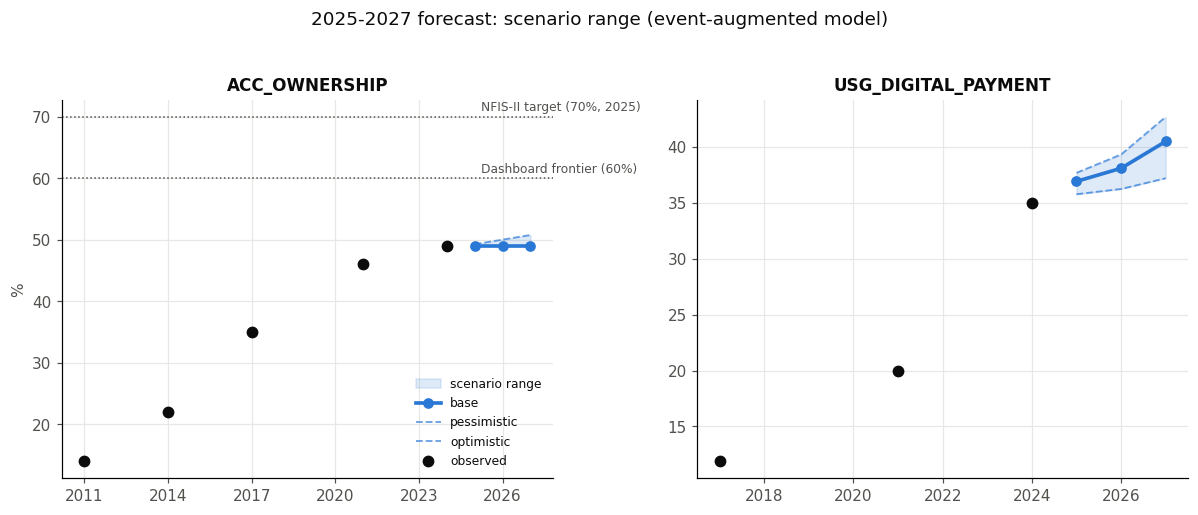

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
scenario_data = {"ACC_OWNERSHIP": access_scenarios, "USG_DIGITAL_PAYMENT": usage_scenarios}
targets_line = {"ACC_OWNERSHIP": [("NFIS-II target (70%, 2025)", 70.0), ("Dashboard frontier (60%)", 60.0)]}

for ax, code_ in zip(axes, TARGETS):
    s = scenario_data[code_]
    ax.fill_between(s.index, s["pessimistic"], s["optimistic"], color=C1, alpha=0.15,
                    label="scenario range")
    ax.plot(s.index, s["base"], color=C1, lw=2.4, marker="o", ms=6, label="base")
    ax.plot(s.index, s["pessimistic"], color=C1, lw=1.2, ls="--", alpha=0.7, label="pessimistic")
    ax.plot(s.index, s["optimistic"], color=C1, lw=1.2, ls="--", alpha=0.7, label="optimistic")
    o = obs[(obs.indicator_code == code_) & (obs.gender == "all")].sort_values("observation_date")
    ax.scatter(o.observation_date.dt.year, o.value_numeric, color=INK, zorder=5, s=45, label="observed")
    for label, val in targets_line.get(code_, []):
        ax.axhline(val, color=INK2, lw=1, ls=":")
        ax.annotate(label, (2025, val), textcoords="offset points", xytext=(4, 4), fontsize=8, color=INK2)
    ax.set_title(code_, fontsize=11)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=7))
    plt.setp(ax.get_xticklabels(), rotation=0)
axes[0].set_ylabel("%"); axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("2025-2027 forecast: scenario range (event-augmented model)", y=1.03)
fig.tight_layout()
save(fig, "scenario_forecast.png"); plt.show()

## 5. Forecast table with uncertainty

Combining both uncertainty tools the brief asks for: the trend model's **statistical prediction
interval** (§2, shown for reference) and the event-augmented model's **scenario range**
(pessimistic–optimistic, §4), which is the primary uncertainty communicator here since the
event-augmented forecast has no native statistical interval.

In [9]:
rows = []
for code_ in TARGETS:
    s = scenario_data[code_]
    t = trend_results[code_].set_index("year")
    for year in FORECAST_YEARS:
        rows.append({
            "indicator": code_, "year": year,
            "event_augmented_base": round(s.loc[year, "base"], 1),
            "scenario_low": round(s.loc[year, "pessimistic"], 1),
            "scenario_high": round(s.loc[year, "optimistic"], 1),
            "trend_baseline": round(t.loc[year, "forecast"], 1),
            "trend_CI_low": round(t.loc[year, "lower"], 1) if pd.notna(t.loc[year, "lower"]) else None,
            "trend_CI_high": round(t.loc[year, "upper"], 1) if pd.notna(t.loc[year, "upper"]) else None,
        })
forecast_table = pd.DataFrame(rows)
forecast_table.to_csv("../reports/forecast_table.csv", index=False)
forecast_table

,indicator,year,event_augmented_base,scenario_low,scenario_high,trend_baseline,trend_CI_low,trend_CI_high
0,ACC_OWNERSHIP,2025,49.0,49.0,49.3,54.8,42.2,67.5
1,ACC_OWNERSHIP,2026,49.0,49.0,50.0,57.7,44.5,70.8
2,ACC_OWNERSHIP,2027,49.0,49.0,50.8,60.5,46.8,74.2
3,USG_DIGITAL_PAYMENT,2025,36.9,35.8,37.7,36.3,-40.0,112.6
4,USG_DIGITAL_PAYMENT,2026,38.1,36.2,39.3,39.5,-43.6,122.7
5,USG_DIGITAL_PAYMENT,2027,40.5,37.2,42.7,42.8,-48.0,133.5


## 6. Interpretation

**What the model predicts.** By 2027: `ACC_OWNERSHIP` reaches roughly **49% (pessimistic/base) to
51% (optimistic)** — essentially flat, because its only empirically validated driver (Telebirr)
fully matured by 2024 and no other cataloged event has a direct link to headline ownership.
`USG_DIGITAL_PAYMENT` reaches roughly **37% (pessimistic) to 40% base to 43% (optimistic)** —
continued, event-driven growth from M-Pesa's ongoing ramp and EthioPay's 2025 launch.

**Which events have the largest potential impact.** For Usage: Telebirr already delivered the
largest realized effect (+12pp calibrated); M-Pesa's ramp and EthioPay's 2025 launch are the
largest *remaining* levers through 2027. For Access: only Fayda's digital-ID rollout and the
NFIS-II strategy have any plausible path to moving headline ownership further — and only if
their currently-unvalidated `enabling` links convert into real account-opening, which the
optimistic scenario prices at a steep discount (0.15×) precisely because it's unproven.

**Key uncertainties.**
1. The entire event-augmented model rests on a **single validation window** (2021→2024) — one
   data point's worth of calibration evidence per pillar.
2. `ACC_OWNERSHIP`'s forecast is unusually fragile: it depends on exactly one link, so if
   Telebirr's effect was itself imprecisely estimated, the whole Access forecast moves with it.
3. The trend baseline (§2) is included for transparency but should not be used for decisions —
   its `USG_DIGITAL_PAYMENT` interval is uninformatively wide, and its `ACC_OWNERSHIP` point
   forecast (60.5% by 2027) contradicts the documented 2021–24 deceleration.
4. No forecast here accounts for macro shocks of the kind already in the catalog (the 2024 FX
   liberalization) recurring during 2025–2027 — a plausible source of further downside not
   modeled.

**Bottom line for the consortium:** absent new Access-specific policy, Ethiopia is on track to
reach roughly 49–51% account ownership by 2027 — far short of both the NFIS-II 70% target and
even a 60% "realistic frontier." Digital payment usage will keep growing on the strength of
already-launched products, reaching an estimated 37–43%. The clearest actionable lever this
analysis identifies is converting Fayda/NFIS-II's *enabling* groundwork into an actual,
measurable, direct effect on account ownership — currently the model has no validated pathway
for that to happen on its own.